# WOD PFL global 1x1 bin
- annual netCDF output
- WOD PFL data
- 2005 to 2022

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import netCDF4 as nc
import xarray as xr
import pandas as pd
import os
import warnings
warnings.filterwarnings('ignore')

In [2]:
# data source identification
Nlev=102
dctd='/glade/campaign/univ/ugit0034/Zhankun/202601/Oxygen_PFL_'
dirname='/glade/derecho/scratch/ito/temporary_WOD_output/'
varname='Oxygen'

In [3]:
# uncomment for 2000m depth
year=2005
ds=xr.open_dataset(f'{dctd}{year}.nc')
z0=ds.depth.to_numpy()
zwod=np.unique(z0)[:Nlev]
zwod

array([0.00e+00, 5.00e+00, 1.00e+01, 1.50e+01, 2.00e+01, 2.50e+01,
       3.00e+01, 3.50e+01, 4.00e+01, 4.50e+01, 5.00e+01, 5.50e+01,
       6.00e+01, 6.50e+01, 7.00e+01, 7.50e+01, 8.00e+01, 8.50e+01,
       9.00e+01, 9.50e+01, 1.00e+02, 1.25e+02, 1.50e+02, 1.75e+02,
       2.00e+02, 2.25e+02, 2.50e+02, 2.75e+02, 3.00e+02, 3.25e+02,
       3.50e+02, 3.75e+02, 4.00e+02, 4.25e+02, 4.50e+02, 4.75e+02,
       5.00e+02, 5.50e+02, 6.00e+02, 6.50e+02, 7.00e+02, 7.50e+02,
       8.00e+02, 8.50e+02, 9.00e+02, 9.50e+02, 1.00e+03, 1.05e+03,
       1.10e+03, 1.15e+03, 1.20e+03, 1.25e+03, 1.30e+03, 1.35e+03,
       1.40e+03, 1.45e+03, 1.50e+03, 1.55e+03, 1.60e+03, 1.65e+03,
       1.70e+03, 1.75e+03, 1.80e+03, 1.85e+03, 1.90e+03, 1.95e+03,
       2.00e+03, 2.10e+03, 2.20e+03, 2.30e+03, 2.40e+03, 2.50e+03,
       2.60e+03, 2.70e+03, 2.80e+03, 2.90e+03, 3.00e+03, 3.10e+03,
       3.20e+03, 3.30e+03, 3.40e+03, 3.50e+03, 3.60e+03, 3.70e+03,
       3.80e+03, 3.90e+03, 4.00e+03, 4.10e+03, 4.20e+03, 4.30e

In [4]:
##os.system('rm -rf '+dirname)
os.system('mkdir -p '+dirname)

0

In [5]:
# prepare grid cells
res=1
xW=np.arange(-180,180,res)
yS=np.arange(-90,90,res)
xC=np.arange(-180,180,res)+res/2
yC=np.arange(-90,90,res)+res/2
xE=np.arange(-180,180,res)+res
yN=np.arange(-90,90,res)+res
# empty array
Nx=np.size(xC)
Ny=np.size(yC)
#
z=zwod
Nz=np.size(z)
Nx=np.size(xC)
Ny=np.size(yC)

In [17]:
def monthly_1deg_bin(Nlev,year,varname):
    # prepare array
    dd_osd=np.zeros((12,Nlev,Ny,Nx),dtype='int')
    sumX_osd=np.zeros((12,Nlev,Ny,Nx))
    # set 1deg lon-lat grid
    Xw=np.arange(-180,180,res)
    Ys=np.arange(-90,90,res)
    # loop over each WOD ragged netCDF file
    dsosd=xr.open_dataset(f'{dctd}{year}.nc')
    Nprof0 = np.size(dsosd.profile)
    datamode=np.zeros(Nprof0)
    print('num of prof = '+str(Nprof0))
    print('reading data...')
    for n in range(Nprof0):
        lonloc=dsosd['lon'][n].to_numpy()+1e-6
        latloc=dsosd['lat'][n].to_numpy()+1e-6
        #print(lonloc,latloc)
        datamode[n]=dsosd['mode'][n]
        # get tracer data
        o2p0=dsosd[varname][n,:Nlev].to_numpy()
        #print(o2p0)
        # read data mode (remove 1s)
        monloc = dsosd['month'][n].to_numpy()
        # get month 
        mind=int(monloc-1)
        if (abs(lonloc)>180)|(abs(latloc)>90)|(datamode[n]==1):
            lonloc=-179.99
            latloc=-89.99
            baddata=1
        else:
            baddata=0
        xind=np.where((Xw>=lonloc-res)&(Xw<lonloc))[0][0]
        yind=np.where((Ys>=latloc-res)&(Ys<latloc))[0][0]
        if (baddata==1):
            tmp_note='no data'
        else:
            # get the profile and its quality flag
            o2p1=np.where(np.isnan(o2p0),0,o2p0)
            pcnt=np.where(np.isnan(o2p0),0,1)
            #print(o2p1)
            #print(pcnt)
            sumX_osd[mind,:,yind,xind]=sumX_osd[mind,:,yind,xind]+o2p1
            dd_osd[mind,:,yind,xind]=dd_osd[mind,:,yind,xind]+pcnt
    return sumX_osd,dd_osd

In [18]:
def save_1deg_bin(dsum,dd,xc,yc,zc,year,var):
    fn=dirname+'/'+var+f'_1x1bin_pfl_'+str(year)+'.nc'
    dave=dsum/dd
    mon=np.arange(f'{year}-01',f'{year+1}-01',dtype='datetime64[M]')
    da=xr.DataArray(data=dave,name=var,dims=['time','depth','lat','lon'],\
                coords={'time':mon,'depth':zc,'lat':yc,'lon':xc})
    ds=da.to_dataset()
    dd=xr.DataArray(data=dd,name='sample_count',dims=['time','depth','lat','lon'],\
                    coords={'time':mon,'depth':zc,'lat':yc,'lon':xc})
    ds['sample_count']=dd
    ds.to_netcdf(fn)
    return 1

In [19]:
YR=np.arange(2005,2026,1)
#
xc=xC.copy()
yc=yC.copy()
zc=z.copy()
#
for yr in YR:
    print('=== working on '+str(yr)+' ===')
    sumX,dd=monthly_1deg_bin(Nlev,yr,varname)
    dummy=save_1deg_bin(sumX,dd,xc,yc,zc,yr,varname)

=== working on 2005 ===
num of prof = 897
reading data...
=== working on 2006 ===
num of prof = 2710
reading data...
=== working on 2007 ===
num of prof = 4195
reading data...
=== working on 2008 ===
num of prof = 7578
reading data...
=== working on 2009 ===
num of prof = 8053
reading data...
=== working on 2010 ===
num of prof = 8352
reading data...
=== working on 2011 ===
num of prof = 9245
reading data...
=== working on 2012 ===
num of prof = 12041
reading data...
=== working on 2013 ===
num of prof = 13715
reading data...
=== working on 2014 ===
num of prof = 16887
reading data...
=== working on 2015 ===
num of prof = 14633
reading data...
=== working on 2016 ===
num of prof = 16084
reading data...
=== working on 2017 ===
num of prof = 15887
reading data...
=== working on 2018 ===
num of prof = 16185
reading data...
=== working on 2019 ===
num of prof = 16987
reading data...
=== working on 2020 ===
num of prof = 16469
reading data...
=== working on 2021 ===
num of prof = 20016
read

In [20]:
ds=xr.open_mfdataset(dirname+'/'+varname+'_1x1bin_pfl_*.nc')

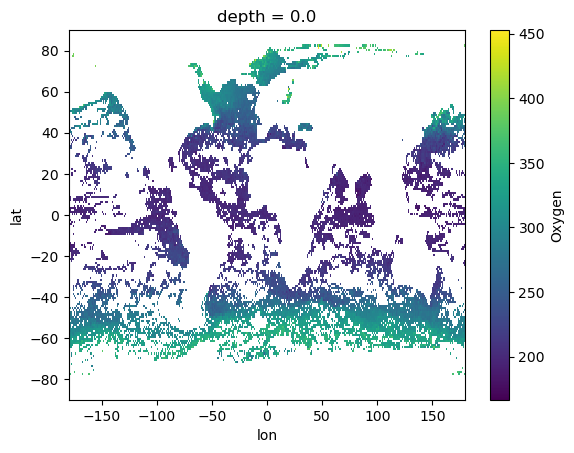

In [21]:
ds[varname][:,0,:,:].mean('time').plot()

In [22]:
ds.to_netcdf(dirname+varname+f'_{res}x{res}bin_pfl_2005-2025.nc')